In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
columnname=['K','B','C']
dataset=pd.read_csv("/content/ex2data2.txt",names=columnname)

In [7]:
print(dataset)

            K         B  C
0    0.051267  0.699560  1
1   -0.092742  0.684940  1
2   -0.213710  0.692250  1
3   -0.375000  0.502190  1
4   -0.513250  0.465640  1
..        ...       ... ..
113 -0.720620  0.538740  0
114 -0.593890  0.494880  0
115 -0.484450  0.999270  0
116 -0.006336  0.999270  0
117  0.632650 -0.030612  0

[118 rows x 3 columns]


In [8]:
dataset.shape

(118, 3)

In [10]:
dataset.describe() #to check if there is any missing values.

,K,B,C
count,118.000000,118.000000,118.000000
mean,0.054779,0.183102,0.491525
std,0.496654,0.519743,0.502060
min,-0.830070,-0.769740,0.000000
25%,-0.372120,-0.254385,0.000000
50%,-0.006336,0.213455,0.000000
75%,0.478970,0.646563,1.000000
max,1.070900,1.108900,1.000000


In [11]:
#normalistion (-1 to 1)
def Normalization(X):
    mean=np.mean(X,axis=0)
    std=np.std(X,axis=0)

    X_norm = (X - mean)/std

    return X_norm , mean , std

In [14]:
#. converts dataframe to array
data_norm=dataset.values
data_norm

m2=len(data_norm)
X2=data_norm[:,0:2].reshape(m2,2)
Y2=data_norm[:,2].reshape(m2,1)

print(X2.shape)
print(Y2.shape)

(118, 2)
(118, 1)


In [15]:
X2, mean_X2, std_X2 = Normalization(X2)
X2 = np.append(np.ones((m2, 1)), X2, axis=1)

print(X2)
theta2=np.zeros((3,1))
print(theta2)
print(mean_X2)
print(std_X2)

[[ 1.         -0.00710129  0.99791805]
 [ 1.         -0.29829632  0.9696688 ]
 [ 1.         -0.54290103  0.98379343]
 [ 1.         -0.8690393   0.61655322]
 [ 1.         -1.14858928  0.5459301 ]
 [ 1.         -1.17188342  0.05158761]
 [ 1.         -0.91562759 -0.28740915]
 [ 1.         -0.72927442 -0.72526668]
 [ 1.         -0.07698778 -1.13488075]
 [ 1.          0.1559638  -1.3467501 ]
 [ 1.          0.66847545 -1.44562247]
 [ 1.          0.9596725  -1.36087473]
 [ 1.          1.18096689 -0.82413904]
 [ 1.          1.37898735 -0.71114205]
 [ 1.          0.99461372  0.58830397]
 [ 1.          0.54033743  0.77192408]
 [ 1.          0.22584623  0.68717634]
 [ 1.         -0.20511367  1.22391203]
 [ 1.         -0.46137152  0.99791805]
 [ 1.         -1.07870684  0.87079644]
 [ 1.         -1.33494245  0.80017332]
 [ 1.         -1.38155096  0.29168688]
 [ 1.         -1.3116483  -0.34390764]
 [ 1.         -0.96221589 -0.88063753]
 [ 1.         -0.34488057 -1.12075613]
 [ 1.          0.29574889

In [16]:
def hypothesis(theta_array,x1,x2):
    return (theta_array[0]+theta_array[1]*x1+theta_array[2])*x2

In [17]:
def cost_function(thetha_array,x1_value,x2_train,y_value,m):
    total_error=0

    for i in range(m):
        total_error+=((thetha_array[0]+thetha_array[1]*x1_value[i]+x2_train[i]*thetha_array[2])-y_value[i])**2

    return (total_error/2*m)

In [19]:
def gradient_descent(thetha_array,x1,x2,y,m,alpha):
    sum0,sum1,sum2=0,0,0

    for i in range(m):
        sum0+=((thetha_array[0]+thetha_array[1]*x1[i]+thetha_array[2]*x2[i])-y[i])
        sum1+=x1[i]*((thetha_array[0]+thetha_array[1]*x1[i]+thetha_array[2]*x2[i])-y[i])
        sum2+=x2[i]*((thetha_array[0]+thetha_array[1]*x1[i]+thetha_array[2]*x2[i])-y[i])
    update_thetha0=thetha_array[0]-(alpha/m)*sum0
    update_thetha1=thetha_array[1]-(alpha/m)*sum1
    update_thetha2=thetha_array[2]-(alpha/m)*sum2
    new_thetha=[update_thetha0,update_thetha1,update_thetha2]
    return new_thetha

In [31]:
def training(x1_train, x2_train, y_train, alpha, iter):
    theta0, theta1, theta2 = 0, 0, 0
    theta_array = [theta0, theta1, theta2]
    m = x1_train.size
    cost_value = []

    for i in range(iter):
        theta_array = gradient_descent(theta_array, x1_train, x2_train, y_train, m, alpha)
        cost_value.append(cost_function(theta_array, x1_train, x2_train, y_train, m))
    y_new = theta_array[0] + theta_array[1]*x1_train + theta_array[2]*x2_train

    plt.figure()
    x = np.arange(0, len(cost_value), step=1)
    plt.plot(x, cost_value)
    plt.xlabel("No. Of Iterations")
    plt.ylabel("Cost Fun. Value")
    plt.show()

    return theta_array

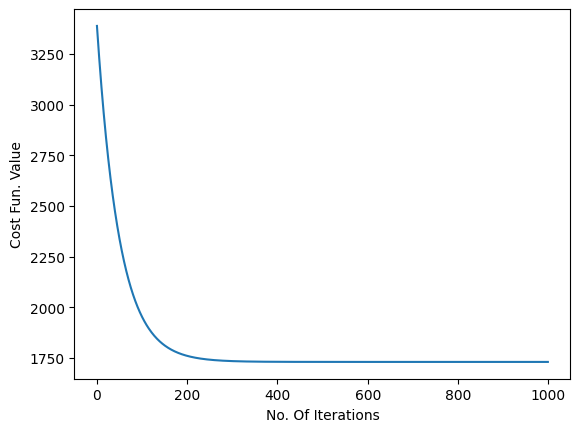

In [32]:
alpha=0.01
iter=1000


result = dataset.iloc[0:dataset.shape[0],2:3]
result


theta_array=training(X2[:,1:2],X2[:,2:3],Y2,alpha,iter)